<a href="https://colab.research.google.com/github/evellynjardini/Data-Analytics---Grupo-24/blob/main/1%20-%20Projeto-Olist-KPIs/notebooks/Receita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
import pandas as pd

# Monta o seu Google Drive
drive.mount('/content/drive')

# Carrega a base consolidada
caminho_arquivo = '/content/drive/MyDrive/df_consolidado.csv'
df_consolidado = pd.read_csv(caminho_arquivo)

df_consolidado.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,...,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_clean,seller_zip_code_prefix,seller_city,seller_state,atrasado
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Sao Paulo,9350.0,Maua,SP,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Barreiras,31570.0,Belo Horizonte,SP,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Vianopolis,14840.0,Guariba,SP,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Sao Goncalo Do Amarante,31842.0,Belo Horizonte,MG,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Santo Andre,8752.0,Mogi Das Cruzes,SP,False


In [9]:
# --- KPI 1: Receita Total ao Longo do Tempo (Mensal) ---

# 1. Filtramos apenas os pedidos entregues diretamente da base consolidada
# (Isso garante que estamos olhando para receita confirmada)
df_receita = df_consolidado[df_consolidado['order_status'] == 'delivered'].copy()

# 2. Garantimos que a coluna de data esteja no formato correto e criamos o Ano-Mês
df_receita['order_purchase_timestamp'] = pd.to_datetime(df_receita['order_purchase_timestamp'])
df_receita['ano_mes'] = df_receita['order_purchase_timestamp'].dt.to_period('M')

# 3. Agregamos a receita (payment_value) e a quantidade por mês
# Como a base é única por pedido, o count('order_id') é exato.
tabela_receita_mensal = (
    df_receita
    .groupby('ano_mes', as_index=False)
    .agg(
        receita_total=('payment_value', 'sum'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 1: RECEITA MENSAL {'='*20}")
print(f"Período: {tabela_receita_mensal['ano_mes'].min()} a {tabela_receita_mensal['ano_mes'].max()}")
print(f"Receita Total (Pedidos Entregues): R$ {df_receita['payment_value'].sum():,.2f}")
print(f"Ticket Médio Mensal: R$ {(df_receita['payment_value'].sum() / df_receita['order_id'].nunique()):,.2f}")
print(f"{'='*53}")

tabela_receita_mensal.head(10)

==================== KPI 1: RECEITA MENSAL ====================
Período: 2016-09 a 2018-08
Receita Total (Pedidos Entregues): R$ 15,422,461.77
Ticket Médio Mensal: R$ 159.85


,ano_mes,receita_total,qtd_pedidos
0,2016-09,0.00,1
1,2016-10,46566.71,265
2,2016-12,19.62,1
3,2017-01,127545.67,750
4,2017-02,271298.65,1653
5,2017-03,414369.39,2546
6,2017-04,390952.18,2303
7,2017-05,567066.73,3546
8,2017-06,490225.60,3135
9,2017-07,566403.93,3872


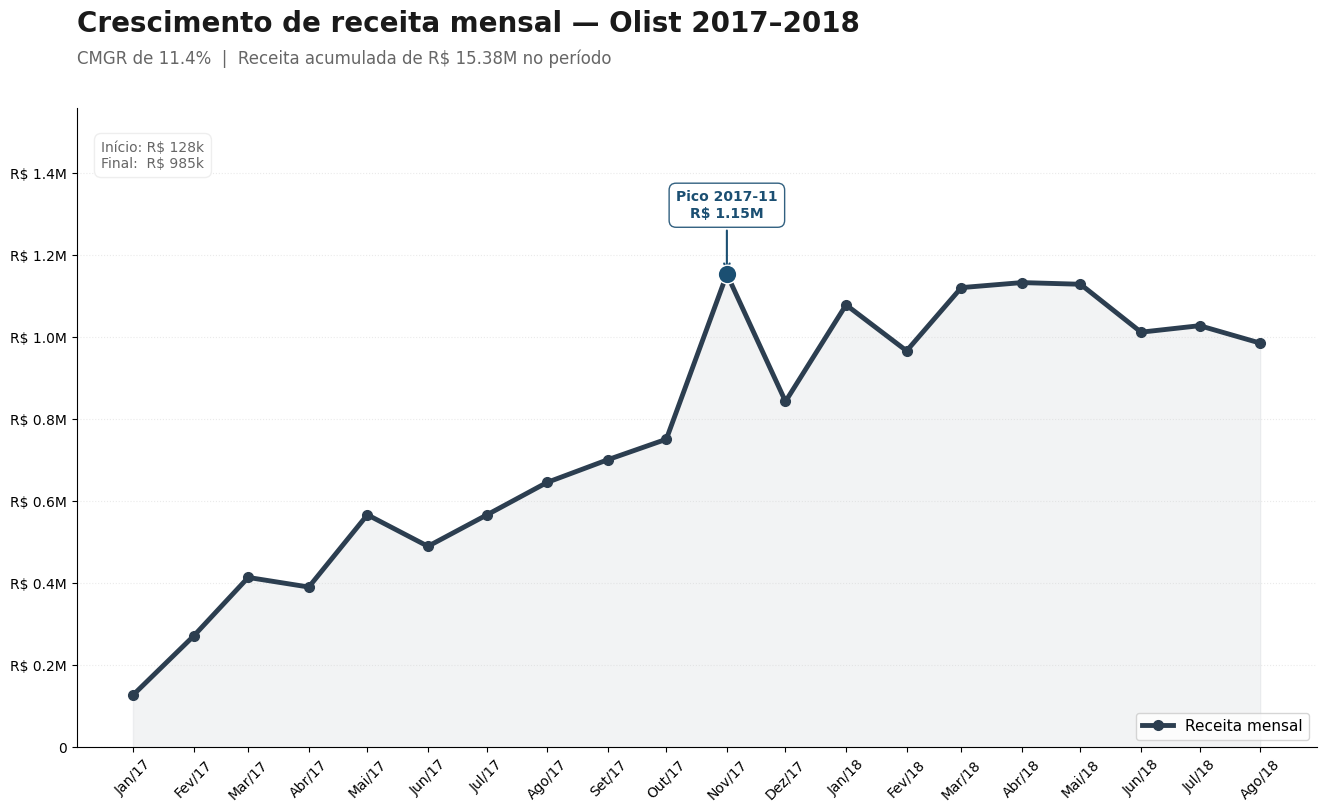

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    tabela_receita_mensal
    .copy()
    .loc[tabela_receita_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = pd.to_datetime(df_plot['ano_mes'].astype(str))

# --- Métricas ---
val_inicial   = df_plot['receita_total'].iloc[0]
val_final     = df_plot['receita_total'].iloc[-1]
multiplo      = val_final / val_inicial
n_meses       = len(df_plot) - 1
cmgr          = (multiplo) ** (1 / n_meses) - 1
receita_total = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']
mes_pico  = df_plot.loc[idx_pico, 'ano_mes']

# --- Cores ---
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'

# --- Visualização ---
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- Caixa de resumo ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal:  R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# --- Linha de receita ---
ax.plot(
    df_plot['data'], df_plot['receita_total'],
    color=AZUL_ESCURO, lw=3.5, marker='o', markersize=7,
    label='Receita mensal', zorder=4
)
ax.fill_between(df_plot['data'], df_plot['receita_total'], alpha=0.06, color=AZUL_ESCURO)

# --- Anotação de pico ---
ax.scatter(data_pico, val_pico, color=COR_PICO, s=180, zorder=5, edgecolor='white')
ax.annotate(
    f'Pico {mes_pico}\nR$ {val_pico/1e6:.2f}M',
    xy=(data_pico, val_pico),
    xytext=(data_pico, val_pico * 1.12),
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
    ha='center', fontweight='bold', color=COR_PICO,
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COR_PICO, alpha=0.9)
)

# --- Eixos ---
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"
))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'
))
plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- Títulos à esquerda ---
ax.text(
    0, 1.12,
    'Crescimento de receita mensal — Olist 2017–2018',
    transform=ax.transAxes, fontsize=20, fontweight='bold',
    color=CINZA_TEXTO, ha='left'
)

ax.text(
    0, 1.07,
    f'CMGR de {cmgr*100:.1f}%  |  Receita acumulada de R$ {receita_total/1e6:.2f}M no período',
    transform=ax.transAxes, fontsize=12, color=CINZA_SUB, ha='left'
)

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=11)
plt.subplots_adjust(top=0.82)
plt.show()

In [11]:
# --- KPI 2: Ticket Médio ao Longo do Tempo (Mensal) ---

# 1. Utilizamos o a tabela_receita_mensal já calculado no KPI receita mensal

# 2. Calculamos o ticket médio mensal (Receita / Quantidade de Pedidos)
tabela_receita_mensal['ticket_medio'] = tabela_receita_mensal['receita_total'] / tabela_receita_mensal['qtd_pedidos']

# --- RESULTADOS ---
print(f"{'='*20} KPI 2: TICKET MÉDIO {'='*20}")

# Calculamos a média real baseada no total de pedidos entregues do df_receita
ticket_medio_geral = df_receita['payment_value'].sum() / df_receita['order_id'].nunique()

print(f"Ticket médio geral (Período Total): R$ {ticket_medio_geral:,.2f}")
print(f"{'='*53}")

# Exibindo as colunas principais
tabela_receita_mensal[['ano_mes', 'qtd_pedidos', 'receita_total', 'ticket_medio']].head(10)

==================== KPI 2: TICKET MÉDIO ====================
Ticket médio geral (Período Total): R$ 159.85


,ano_mes,qtd_pedidos,receita_total,ticket_medio
0,2016-09,1,0.00,0.000000
1,2016-10,265,46566.71,175.723434
2,2016-12,1,19.62,19.620000
3,2017-01,750,127545.67,170.060893
4,2017-02,1653,271298.65,164.125015
5,2017-03,2546,414369.39,162.753099
6,2017-04,2303,390952.18,169.757785
7,2017-05,3546,567066.73,159.917296
8,2017-06,3135,490225.60,156.371802
9,2017-07,3872,566403.93,146.282007


In [ ]:
# --- KPI 3: Receita por Categoria ---

# 1. Filtramos apenas pedidos entregues da base consolidada
df_entregues = df_consolidado[df_consolidado['order_status'] == 'delivered'].copy()

# 2. Tratamos categorias ausentes (Data Cleaning dentro do KPI)
# Usaremos 'product_category_name_english' que é o nome comum após a tradução
col_categoria = 'product_category_name_english'

if col_categoria in df_entregues.columns:
    df_entregues[col_categoria] = df_entregues[col_categoria].fillna('sem_categoria')
else:
    # Caso sua coluna tenha outro nome, como 'product_category_name'
    col_categoria = 'product_category_name'
    df_entregues[col_categoria] = df_entregues[col_categoria].fillna('sem_categoria')

# 3. Agregamos os valores por categoria
# Como a base é consolidada por pedido, price e freight_value já são os totais do pedido
tabela_receita_por_categoria = (
    df_entregues
    .groupby(col_categoria, as_index=False)
    .agg(
        receita_produtos=('price', 'sum'),
        receita_frete=('freight_value', 'sum'),
        qtd_pedidos=('order_id', 'count') # Cada linha é um pedido único
    )
    .assign(receita_total=lambda x: x['receita_produtos'] + x['receita_frete'])
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 3: RECEITA POR CATEGORIA {'='*20}")
print(f"Total de categorias analisadas: {tabela_receita_por_categoria[col_categoria].nunique()}")
print(f"Receita da categoria 'sem_categoria': R$ {tabela_receita_por_categoria.loc[tabela_receita_por_categoria[col_categoria]=='sem_categoria', 'receita_total'].sum():,.2f}")
print(f"{'='*60}")

tabela_receita_por_categoria.head(15)